# Handling NaN values

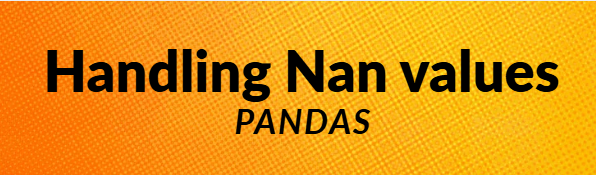

<div class="alert alert-warning">     
<b> Table of Contents </b>

1. [Introduction](#introduction)
2. [How to detect NaN Values?](#nan)
3. [How to fill NaN values?](#fillna)
4. [How to drop NaN values?](#remove)

<div class="alert alert-warning">
    <b> I. <i>Introduction</i></b>
    <a id="introduction"></a></div>

The special values `NaN`, `None` and `NaT` are elements that can be found in dataframes and indicate that the data does not exist or is unavailable. Each of these values is used in a specific context:

- ``NaN (Not a Number)``: NaN is a special representation for numerical values that are invalid or unavailable. It is mainly used in series or dataframes with numerical data. When performing mathematical or statistical operations on data containing NaN, the result will often be NaN. To identify NaN in Pandas, you can use the `pd.isna()` function.

- ``None``: None is a special constant in Python that is used to represent the absence of a value or the non-existence of a variable. To check if a value is None, you can use the equality operator (==) or the ``pd.isna()`` function.

- ``NaT (Not a Timestamp)``: NaT is a special representation for datetime values that are unavailable or undefined. This value is primarily used in columns containing dates and times. You can identify NaT by using the ``pd.isna()`` or ``pd.isnull()`` functions on date columns.

In [67]:
import pandas as pd
import numpy as np

In [68]:
df = pd.read_csv("WHO.csv")
df.head()

,Country,CountryID,Continent,Adolescent fertility rate (%),Adult literacy rate (%),Gross national income per capita (PPP international $),Net primary school enrolment ratio female (%),Net primary school enrolment ratio male (%),Population (in thousands) total,Population annual growth rate (%),...,Total_CO2_emissions,Total_income,Total_reserves,Trade_balance_goods_and_services,Under_five_mortality_from_CME,Under_five_mortality_from_IHME,Under_five_mortality_rate,Urban_population,Urban_population_growth,Urban_population_pct_of_total
0,Afghanistan,1,1,151.0,28.0,NaN,NaN,NaN,26088.0,4.0,...,692.50,NaN,NaN,NaN,257.00,231.9,257.00,5740436.0,5.44,22.9
1,Albania,2,2,27.0,98.7,6000.0,93.0,94.0,3172.0,0.6,...,3499.12,4.790000e+09,78.14,-2.040000e+09,18.47,15.5,18.47,1431793.9,2.21,45.4
2,Algeria,3,3,6.0,69.9,5940.0,94.0,96.0,33351.0,1.5,...,137535.56,6.970000e+10,351.36,4.700000e+09,40.00,31.2,40.00,20800000.0,2.61,63.3
3,Andorra,4,2,NaN,NaN,NaN,83.0,83.0,74.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,5,3,146.0,67.4,3890.0,49.0,51.0,16557.0,2.8,...,8991.46,1.490000e+10,27.13,9.140000e+09,164.10,242.5,164.10,8578749.0,4.14,53.3


<div class="alert alert-warning">
    <b> II. <i>How to detect NaN values?</i></b>
    <a id="nan"></a></div>

``isna().sum()``: We can count the NaN values in the whole dataframe.

In [69]:
df.isna().sum()

Country                            0
CountryID                          0
Continent                          0
Adolescent fertility rate (%)     25
Adult literacy rate (%)           71
                                  ..
Under_five_mortality_from_IHME    32
Under_five_mortality_rate         21
Urban_population                  14
Urban_population_growth           14
Urban_population_pct_of_total     14
Length: 358, dtype: int64

<div class="alert alert-info">
Which columns contain invalid data: NaN, NaT, None? 


<div class="alert alert-info">
How many samples are correct?

Use ``notna()`` or ``notnull()``.

<div class="alert alert-warning">
    <b> III. <i>How to fill NaN values?</i></b>
    <a id="fillna"></a></div>

We can ignore the invalid samples or fill them by replacing unknown samples with other values. 

``fillna``: Basically, it replaces Nan values with a constant or with the value of the previous row/column.

In [70]:
df2 = df.loc[:, ["Country", "Urban_population","Urban_population_growth"]]
df2

,Country,Urban_population,Urban_population_growth
0,Afghanistan,5740436.0,5.44
1,Albania,1431793.9,2.21
2,Algeria,20800000.0,2.61
3,Andorra,NaN,NaN
4,Angola,8578749.0,4.14
...,...,...,...
197,Vietnam,21900000.0,2.90
198,West Bank and Gaza,2596216.0,3.33
199,Yemen,5759120.5,4.37
200,Zambia,4017411.0,1.95


In [71]:
df3 = df2.fillna(0) 
df3.head()

,Country,Urban_population,Urban_population_growth
0,Afghanistan,5740436.0,5.44
1,Albania,1431793.9,2.21
2,Algeria,20800000.0,2.61
3,Andorra,0.0,0.00
4,Angola,8578749.0,4.14


__Mean__: We can fill the values with the mean.

<div class="alert alert-info">
Add the mean.

In [72]:
#df2.fillna() # ADD THE MEAN

__Fill with interpolated data__: We can use ``interpolate()``, which is a function to estimate missing values (NaN) based on nearby known values. Instead of deleting data or entering a 0, try to ‘guess’ the value. 

If we use it without any parameter, it assumes the data changes linearly between points. We can put the following parameters: 

- __axis=1__: The NaN is estimated using values from the same row.
- __method="pad"__ or __ffill()__: Fill in with the last known value from here onwards.
- __method="nearest"__: Round up to the nearest value.

<div class="alert alert-info">
Try different interpolations.

In [73]:
print(df2.interpolate())

                Country  Urban_population  Urban_population_growth
0           Afghanistan         5740436.0                    5.440
1               Albania         1431793.9                    2.210
2               Algeria        20800000.0                    2.610
3               Andorra        14689374.5                    3.375
4                Angola         8578749.0                    4.140
..                  ...               ...                      ...
197             Vietnam        21900000.0                    2.900
198  West Bank and Gaza         2596216.0                    3.330
199               Yemen         5759120.5                    4.370
200              Zambia         4017411.0                    1.950
201            Zimbabwe         4709965.0                    1.900

[202 rows x 3 columns]


C:\Users\Aina\AppData\Local\Temp\ipykernel_32260\3419578096.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  print(df2.interpolate())


In [74]:
df = pd.DataFrame(np.random.randn(5, 3), 
                     index=['a', 'b', 'c', 'd', 'e'],
                     columns=['one', 'two', 'three'])
df.two[df.two<0]=np.nan

C:\Users\Aina\AppData\Local\Temp\ipykernel_32260\2052112347.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.two[df.two<0]=np.nan


In [75]:
print(df.interpolate())

        one       two     three
a -0.740488  0.060423 -1.782326
b -0.652051  0.086869 -0.837340
c  0.177218  2.121007 -1.313939
d -1.074380  1.669306 -1.118598
e  0.932675  1.217605  0.120205


<div class="alert alert-warning">
    <b> IV. <i>How to drop NaN values?</i></b>
    <a id="remove"></a></div>

We can also remove the NaN values.

``dropna``: Removes Nan from the dataframe, removing the rows that have at least one NaN.
if we put axis=0 as parameter removes the rows that have at least one NaN, if we put axis=1, removes the columns.

In [76]:
print(df.dropna())

        one       two     three
a -0.740488  0.060423 -1.782326
b -0.652051  0.086869 -0.837340
c  0.177218  2.121007 -1.313939
e  0.932675  1.217605  0.120205


In [77]:
df.dropna(axis=1)

,one,three
a,-0.740488,-1.782326
b,-0.652051,-0.837340
c,0.177218,-1.313939
d,-1.074380,-1.118598
e,0.932675,0.120205


<div class="alert alert-info">

__Exercise__
1. Count how many countries have at least one NaN value from the WHO.csv
2. Select rows 100 to 150 and columns 1st, 3rd, and 10th and count how many NaN values are present. 
3. Replace them with any of the techniques seen.
4. Remove rows with NaN from the original dataframe. 